In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# imports
import os, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [ ]:
DATA_ROOT = '/content/drive/MyDrive/Datasets/Plant Village-Processed/Plant Village Processed/Tomato'
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 40
LR_MAX       = 3e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
DROPOUT_P    = 0.3
NUM_WORKERS  = 2

NUM_CLASSES = len(os.listdir(os.path.join(DATA_ROOT, 'Train')))
print(f'Classes found: {NUM_CLASSES}')

Classes found: 6


In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [ ]:
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, 'Train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, 'Val'),   transform=val_tf)

class_counts   = np.bincount(train_ds.targets)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Classes: {train_ds.classes}')

Train: 11108 | Val: 2502
Classes: ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [ ]:
# MobileNetV2 from Scratch
def conv_3x3_bn(in_ch, out_ch, stride):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU6(inplace=True)
    )

def conv_1x1_bn(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 1, 1, 0, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU6(inplace=True)
    )

class InvertedResidual(nn.Module):
    def __init__(self, in_ch, out_ch, stride, expand_ratio):
        super().__init__()
        self.stride = stride
        hidden_dim = int(round(in_ch * expand_ratio))
        self.use_res_connect = self.stride == 1 and in_ch == out_ch

        layers = []
        if expand_ratio != 1:
            # pw (pointwise expansion)
            layers.append(conv_1x1_bn(in_ch, hidden_dim))

        layers.extend([
            # dw (depthwise)
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            # pw-linear (projection)
            nn.Conv2d(hidden_dim, out_ch, 1, 1, 0, bias=False),
            nn.BatchNorm2d(out_ch),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV2(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT_P):
        super().__init__()
        # Setting based on the standard MobileNetV2 paper
        self.configs = [
            # t, c, n, s (expansion factor, channels, number of blocks, stride)
            [1, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        # Stem layer
        input_channel = 32
        self.stem = conv_3x3_bn(3, input_channel, 2)

        # Build inverted residual blocks
        layers = []
        for t, c, n, s in self.configs:
            for i in range(n):
                stride = s if i == 0 else 1
                layers.append(InvertedResidual(input_channel, c, stride, expand_ratio=t))
                input_channel = c
        self.features = nn.Sequential(*layers)

        # Last several layers
        self.conv_last = conv_1x1_bn(input_channel, 1280)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, num_classes)
        )

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.conv_last(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# Instantiate the model
model = MobileNetV2().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total/1e6:.2f}M')

Total parameters: 2.23M


In [ ]:
# Loss / Optimizer / Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

optimizer = AdamW(model.parameters(), lr=LR_MAX / 25, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=len(train_dl),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

scaler = GradScaler()

In [ ]:
from tqdm import tqdm
import copy, time

def run_epoch(model, loader, criterion, optimizer, scheduler, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    desc = 'Train' if train else 'Val'
    pbar = tqdm(loader, desc=desc, leave=False, ncols=80)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in pbar:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
            else:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

            pbar.set_postfix(loss=f'{total_loss/total:.4f}',
                             acc=f'{correct/total:.2%}')

    return total_loss / total, correct / total


CKPT_DIR = '/content/drive/MyDrive/Datasets/Plant Village-Processed/Plant Village Processed'

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc, best_wts = 0.0, copy.deepcopy(model.state_dict())
patience, no_improve = 5, 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, scaler, train=True)
    va_loss, va_acc = run_epoch(model, val_dl,   criterion, optimizer, scheduler, scaler, train=False)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
        tag = ' ★'
        # Renamed file to mobilenet_checkpoint_best.pth
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_val_acc': best_acc,
            'history': history
        }, f'{CKPT_DIR}/mobilenet_checkpoint_best.pth')
    else:
        no_improve += 1
        tag = ''

    # Renamed file to mobilenet_checkpoint_latest.pth
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_acc,
        'history': history
    }, f'{CKPT_DIR}/mobilenet_checkpoint_latest.pth')

    print(f'Epoch {epoch:>3}  '
          f'TrLoss={tr_loss:.4f}  TrAcc={tr_acc:.2%}  '
          f'VaLoss={va_loss:.4f}  VaAcc={va_acc:.2%}  '
          f'{elapsed:.0f}s{tag}')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

model.load_state_dict(best_wts)
print(f'\nBest val accuracy: {best_acc:.4%}')

Epoch   1  TrLoss=1.5982  TrAcc=36.46%  VaLoss=1.3024  VaAcc=53.28%  1551s ★


Epoch   2  TrLoss=1.3134  TrAcc=54.27%  VaLoss=1.0628  VaAcc=67.35%  481s ★


Epoch   3  TrLoss=1.2016  TrAcc=60.84%  VaLoss=1.0318  VaAcc=72.70%  254s ★


Epoch   4  TrLoss=1.0952  TrAcc=66.58%  VaLoss=1.0682  VaAcc=73.30%  172s ★


Epoch   5  TrLoss=1.0287  TrAcc=70.63%  VaLoss=1.0324  VaAcc=73.22%  144s


...

Epoch  36  TrLoss=0.4700  TrAcc=97.94%  VaLoss=0.4331  VaAcc=99.60%  131s ★


Epoch  37  TrLoss=0.4724  TrAcc=97.70%  VaLoss=0.4331  VaAcc=99.56%  133s


Epoch  38  TrLoss=0.4647  TrAcc=98.06%  VaLoss=0.4322  VaAcc=99.60%  129s


Epoch  39  TrLoss=0.4682  TrAcc=97.98%  VaLoss=0.4321  VaAcc=99.52%  129s


Epoch  40  TrLoss=0.4650  TrAcc=98.16%  VaLoss=0.4317  VaAcc=99.64%  130s ★

Best val accuracy: 99.6403%


In [ ]:
# Save the final best MobileNetV2 model
torch.save({
    'model_state': best_wts,
    'classes': train_ds.classes,
    'best_val_acc': best_acc
}, f'{CKPT_DIR}/mobilenetv2_best.pth')

print(f'Saved best MobileNetV2 model with val acc: {best_acc:.4%}')

Saved best MobileNetV2 model with val acc: 99.6403%


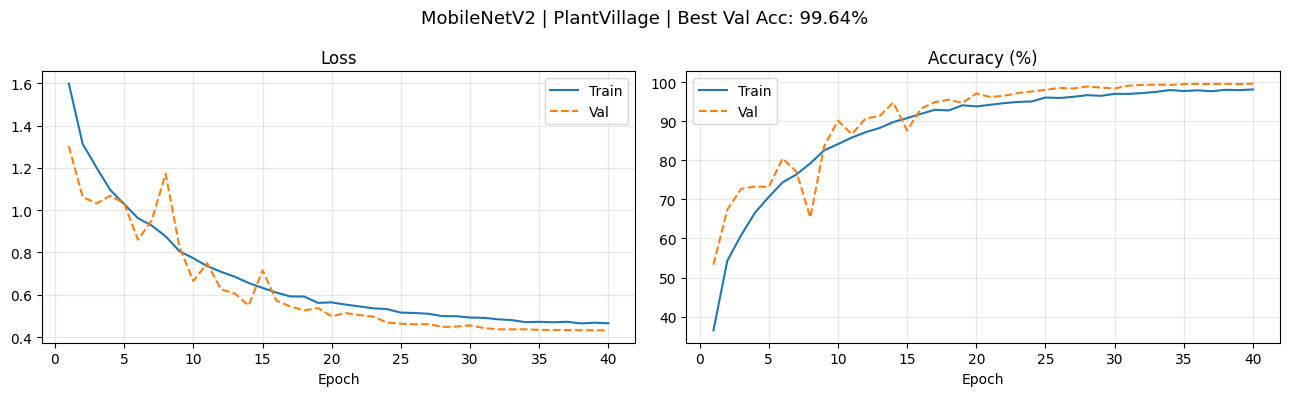

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)

# Plot Loss
axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot Accuracy
axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val', linestyle='--')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Update title and save with a new filename
plt.suptitle(f'MobileNetV2 | PlantVillage | Best Val Acc: {best_acc:.2%}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/mobilenetv2_curves.png', dpi=150)
plt.show()

In [ ]:
# Evaluation on Test/Val Set for MobileNetV2
test_path = os.path.join(DATA_ROOT, 'Test')
eval_path = test_path if os.path.exists(test_path) else os.path.join(DATA_ROOT, 'Val')

eval_ds = datasets.ImageFolder(eval_path, transform=val_tf)
eval_dl = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=0, pin_memory=True)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in eval_dl:
        with autocast():
            # The model variable now holds your MobileNetV2 architecture
            out = model(imgs.to(DEVICE))
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
overall    = (all_preds == all_labels).float().mean().item()

print(f'\nOverall accuracy on {os.path.basename(eval_path)} (MobileNetV2): {overall:.4%}\n')

for i, cls in enumerate(eval_ds.classes):
    mask = (all_labels == i)
    acc  = (all_preds[mask] == all_labels[mask]).float().mean().item()
    print(f'  {cls:40s}  {acc:6.2%}  (n={mask.sum().item()})')


Overall accuracy on Test (MobileNetV2): 100.0000%

  Bacterial Spot                            100.00%  (n=43)
  Early Blight                              100.00%  (n=48)
  Healthy                                   100.00%  (n=49)
  Late Blight                               100.00%  (n=47)
  Septoria Leaf Spot                        100.00%  (n=44)
  Yellow Leaf Curl Virus                    100.00%  (n=49)


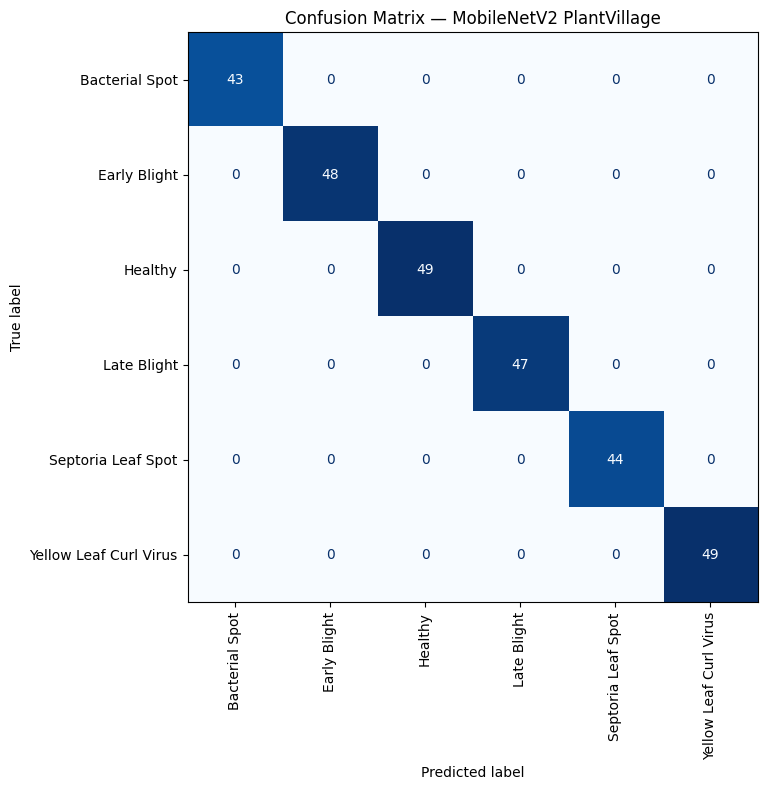

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix using the predictions from the previous cell
cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

# Dynamic figure size based on the number of classes
fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES//2), max(8, NUM_CLASSES//2)))

# Plot the matrix
disp = ConfusionMatrixDisplay(cm, display_labels=eval_ds.classes)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')

plt.title('Confusion Matrix — MobileNetV2 PlantVillage')
plt.tight_layout()

# Save as a new file to distinguish from ResNet-18
plt.savefig(f'{CKPT_DIR}/mobilenetv2_cm.png', dpi=120)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Generate and print the report for MobileNetV2
# Ensure you are using the 'all_labels' and 'all_preds' generated from the MobileNetV2 evaluation cell
print("MobileNetV2 Classification Report:\n")
print(classification_report(all_labels.numpy(), all_preds.numpy(), target_names=eval_ds.classes))

MobileNetV2 Classification Report:

                        precision    recall  f1-score   support

        Bacterial Spot       1.00      1.00      1.00        43
          Early Blight       1.00      1.00      1.00        48
               Healthy       1.00      1.00      1.00        49
           Late Blight       1.00      1.00      1.00        47
    Septoria Leaf Spot       1.00      1.00      1.00        44
Yellow Leaf Curl Virus       1.00      1.00      1.00        49

              accuracy                           1.00       280
             macro avg       1.00      1.00      1.00       280
          weighted avg       1.00      1.00      1.00       280

